In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [2]:
df = pd.read_csv("electricity_cost_dataset.csv")

In [ ]:
df

In [3]:
# Clean column names
df.columns = df.columns.str.replace(" ", "_")
# Clean variable names
df["structure_type"] = df["structure_type"].replace("Mixed-use", "Mixed")

In [ ]:
df

In [6]:
# Define numerics and categorics to analyze
numerics = df.drop("electricity_cost", axis=1).select_dtypes("number").columns.to_list()
categorics = df.select_dtypes("object").columns.to_list()

# EDA

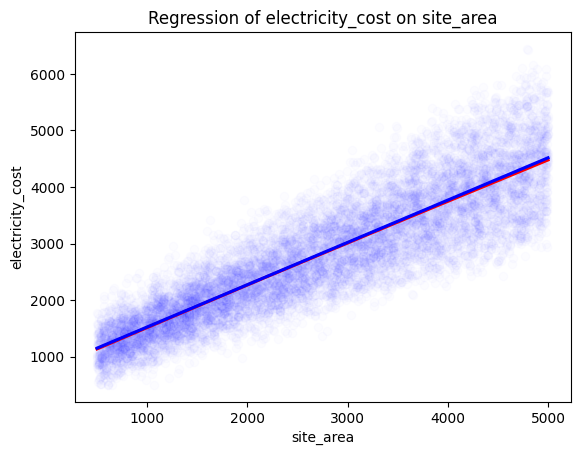

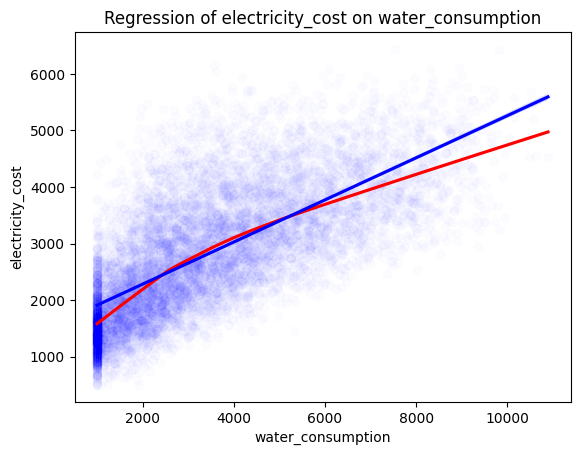

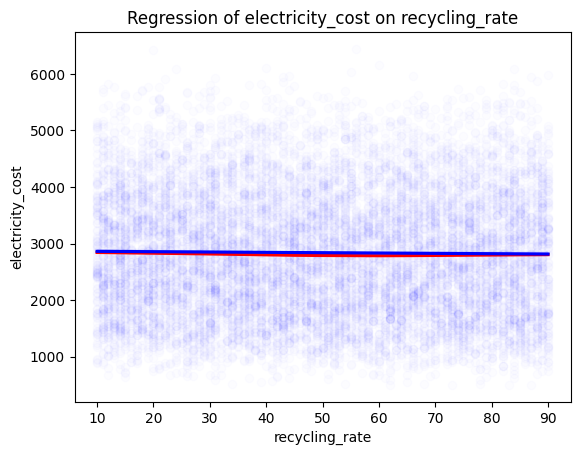

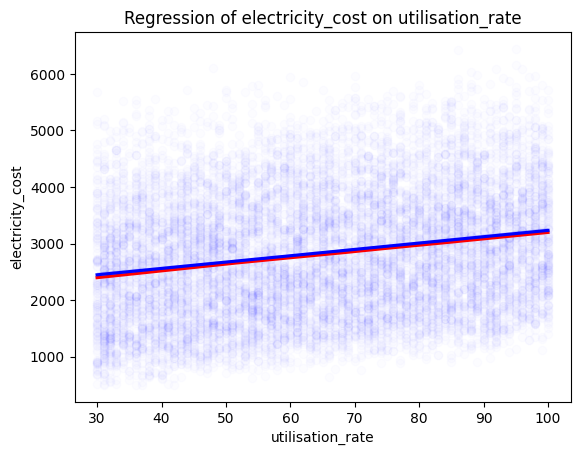

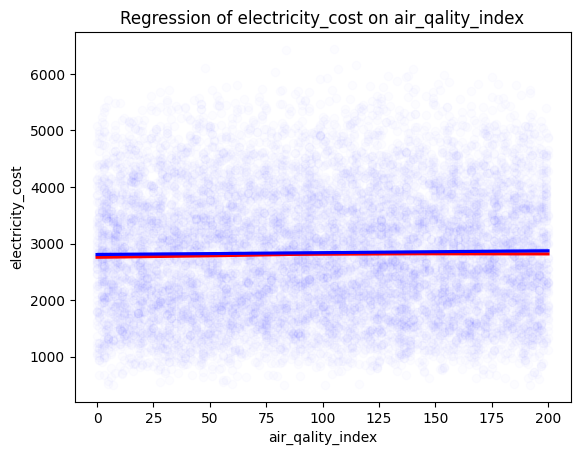

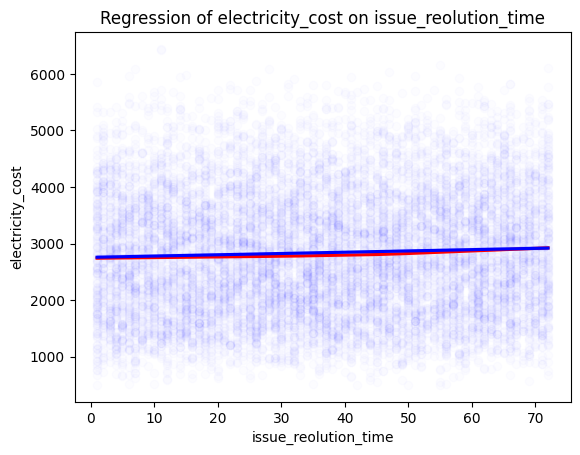

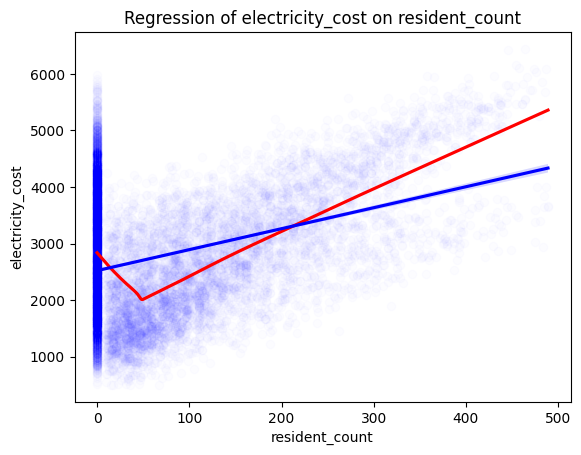

In [11]:
# Plot numerics against target and check linearity
for feature in numerics:
    sns.regplot(data=df, x=feature, y="electricity_cost", lowess=True, color="red", scatter=False)
    sns.regplot(data=df, x=feature, y="electricity_cost", lowess=False, color="blue", scatter=True, scatter_kws={"alpha": 0.01})
    plt.title(f"Regression of electricity_cost on {feature}")
    plt.show()

In [21]:
df["water_consumption"] = np.log(df["water_consumption"])

<Axes: >

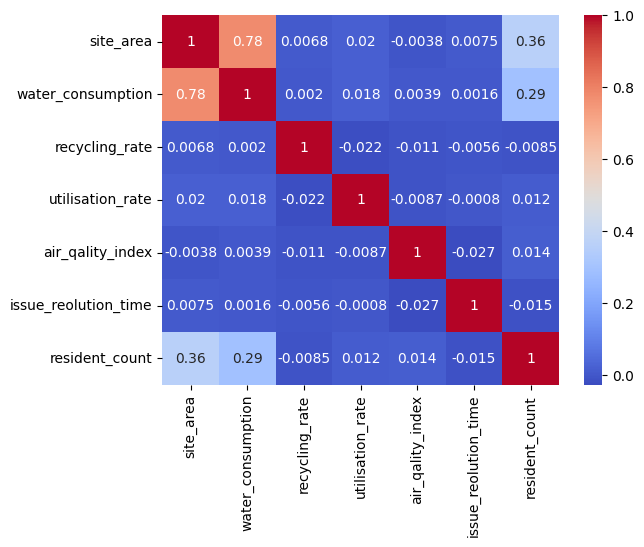

In [45]:
sns.heatmap(df[numerics].corr(), cmap="coolwarm", annot=True)

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


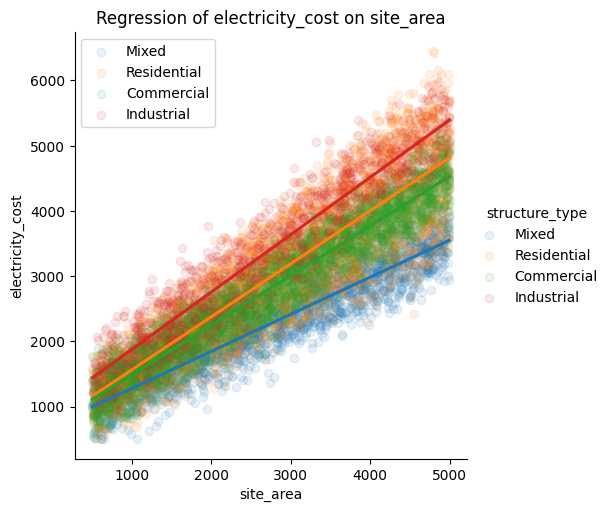

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


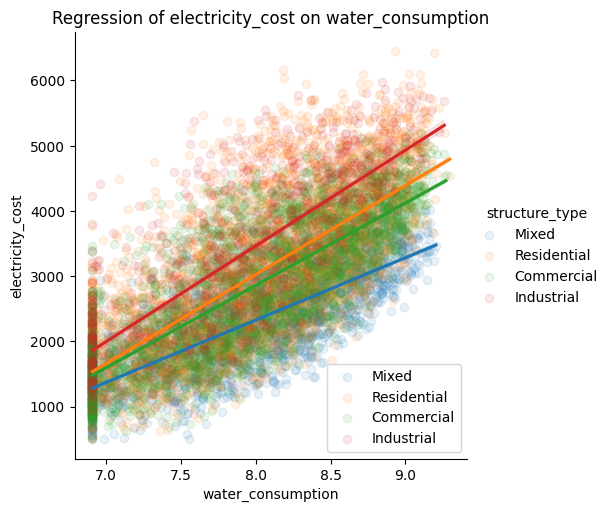

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


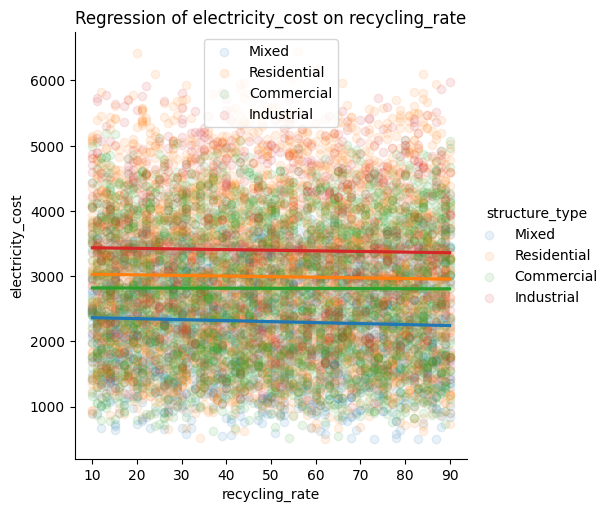

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


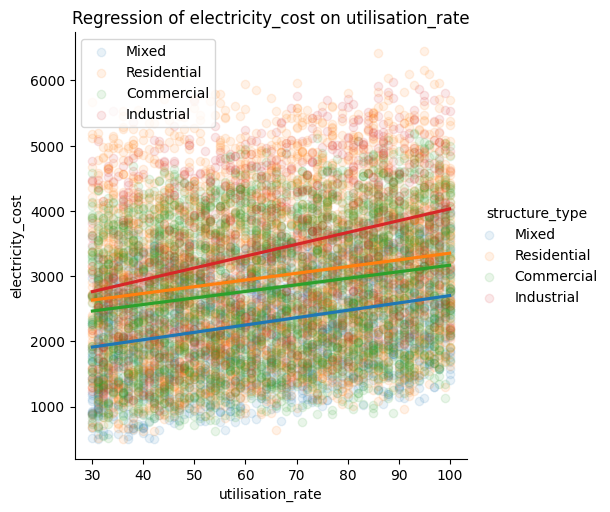

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


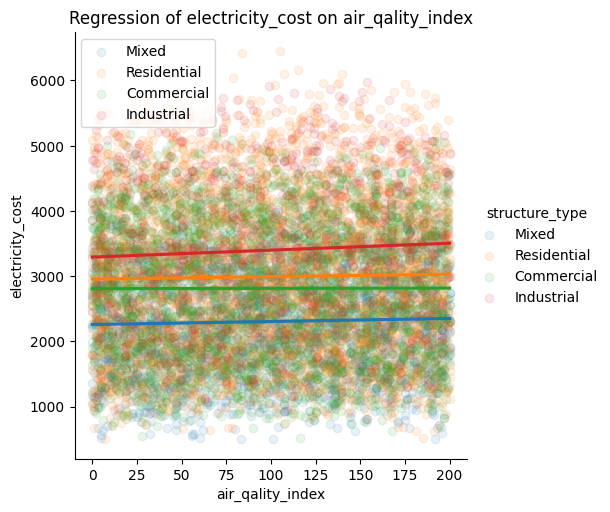

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


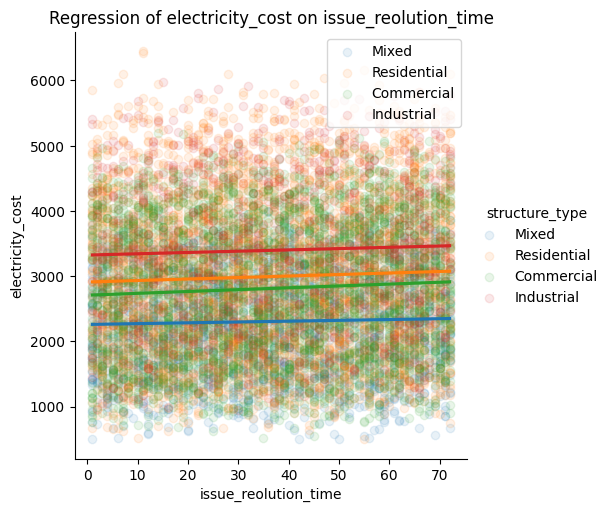

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


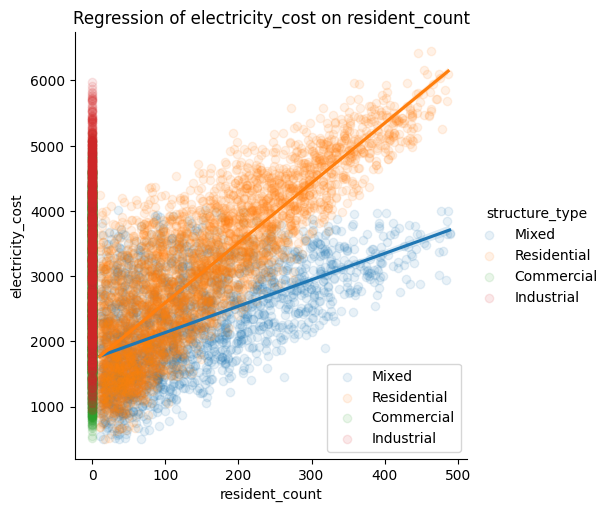

In [22]:
# Plot numerics against target and check linearity
for feature in numerics:
    sns.lmplot(data=df, x=feature, y="electricity_cost", lowess=False, scatter=True, scatter_kws={"alpha": 0.1}, hue="structure_type")
    plt.title(f"Regression of electricity_cost on {feature}")
    plt.legend()
    plt.show()

<Axes: xlabel='structure_type', ylabel='electricity_cost'>

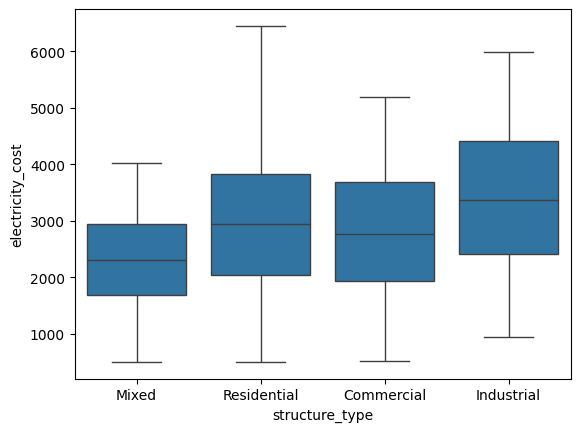

In [23]:
# Plot categorics
sns.boxplot(df, x="structure_type", y="electricity_cost")

In [ ]:
# We should retain the log-transformed water consumption, and we should include an interaction term for mixed, residential and resident_count

# Prepare data for modelling

In [30]:
X = df[numerics+categorics].copy()
y = df["electricity_cost"].copy()

# Add constant
X = sm.add_constant(X)

# Get dummies with commercial as baseline category
dummies = pd.get_dummies(X["structure_type"], prefix="structure", dtype=int, drop_first=True)

In [32]:
# Join dfs
X = pd.concat([X.drop("structure_type", axis=1), dummies], axis=1)

In [33]:
X

,const,site_area,water_consumption,recycling_rate,utilisation_rate,air_qality_index,issue_reolution_time,resident_count,structure_Industrial,structure_Mixed,structure_Residential
0,1.0,1360,7.831617,69,52,188,1,72,0,1,0
1,1.0,4272,7.751045,50,76,165,65,261,0,1,0
2,1.0,3592,7.901377,20,94,198,39,117,0,1,0
3,1.0,966,6.907755,13,60,74,3,35,0,0,1
4,1.0,4926,8.697847,23,65,32,57,185,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,1.0,708,7.218910,76,77,22,23,0,0,0,0
9996,1.0,2960,8.111328,22,72,100,47,54,0,0,1
9997,1.0,3942,7.794411,61,43,48,49,0,0,0,0
9998,1.0,3211,8.442254,72,73,105,55,0,0,0,0


In [34]:
# Construct interaction variables
X["Mixed:resident_count"] = X["structure_Mixed"] * X["resident_count"]
X["Residential:resident_count"] = X["structure_Residential"] * X["resident_count"]

In [35]:
X

,const,site_area,water_consumption,recycling_rate,utilisation_rate,air_qality_index,issue_reolution_time,resident_count,structure_Industrial,structure_Mixed,structure_Residential,Mixed:resident_count,Residential:resident_count
0,1.0,1360,7.831617,69,52,188,1,72,0,1,0,72,0
1,1.0,4272,7.751045,50,76,165,65,261,0,1,0,261,0
2,1.0,3592,7.901377,20,94,198,39,117,0,1,0,117,0
3,1.0,966,6.907755,13,60,74,3,35,0,0,1,0,35
4,1.0,4926,8.697847,23,65,32,57,185,0,0,1,0,185
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.0,708,7.218910,76,77,22,23,0,0,0,0,0,0
9996,1.0,2960,8.111328,22,72,100,47,54,0,0,1,0,54
9997,1.0,3942,7.794411,61,43,48,49,0,0,0,0,0,0
9998,1.0,3211,8.442254,72,73,105,55,0,0,0,0,0,0


In [36]:
# Split into train-test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [39]:
# Standardize numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
standardize = numerics + ["Mixed:resident_count", "Residential:resident_count"]
X_train[standardize] = scaler.fit_transform(X_train[standardize])
X_test[standardize] = scaler.transform(X_test[standardize])

# Modelling

In [81]:
# Fit OLS model
OLS = sm.OLS(y_train, X_train).fit()
print(OLS.summary())

from sklearn.metrics import mean_squared_error as MSE, mean_absolute_error as MAE, r2_score
OLS_preds = OLS.predict(X_test)
print(f"R2: {r2_score(y_test, OLS_preds)}")
print(f"MSE: {MSE(y_test, OLS_preds)}")
print(f"MAE: {MAE(y_test, OLS_preds)}")

                            OLS Regression Results                            
Dep. Variable:       electricity_cost   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                 1.427e+04
Date:                Tue, 29 Jul 2025   Prob (F-statistic):               0.00
Time:                        14:24:01   Log-Likelihood:                -55337.
No. Observations:                8000   AIC:                         1.107e+05
Df Residuals:                    7988   BIC:                         1.108e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## Check model fit

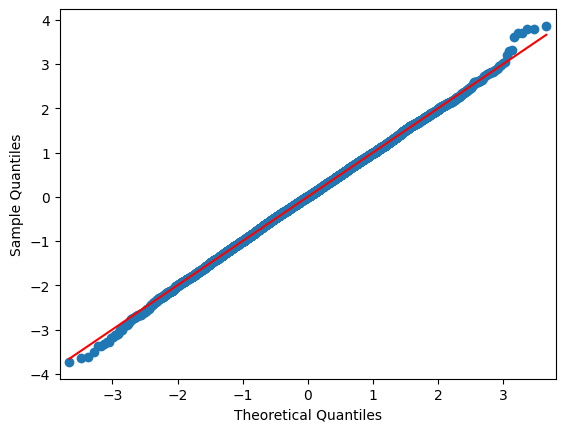

In [82]:
qq = sm.qqplot(OLS.resid_pearson, line="s")

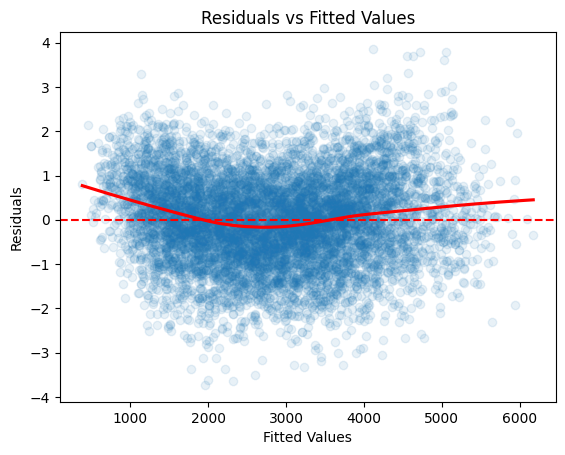

In [80]:
fitted = sns.regplot(x=OLS.fittedvalues, y=OLS.resid_pearson, lowess=True, scatter_kws={"alpha": 0.1}, line_kws={"color": "red"})
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

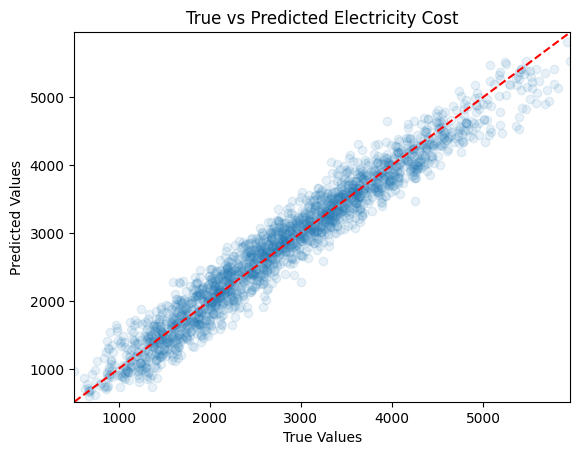

In [85]:
# Prediction against true values
plt.scatter(y_test, OLS_preds, alpha=0.1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Electricity Cost")
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.show()

# Cooks diagnostics

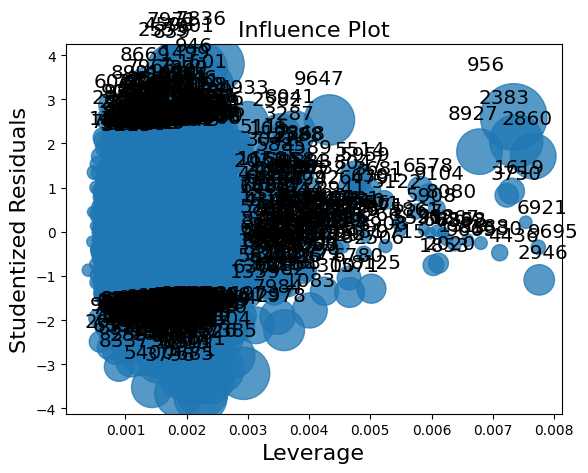

In [ ]:
cooks = sm.graphics.influence_plot(OLS, criterion="cooks")

In [71]:
top_10_leverage_idx = OLS.get_influence().summary_frame()[["cooks_d", "hat_diag"]].sort_values(by="hat_diag", ascending=False).head(10).index

In [72]:
X_train.loc[top_10_leverage_idx]

,const,site_area,water_consumption,recycling_rate,utilisation_rate,air_qality_index,issue_reolution_time,resident_count,structure_Industrial,structure_Mixed,structure_Residential,Mixed:resident_count,Residential:resident_count
2946,1.0,1.723323,1.233683,-1.266477,-1.654393,1.332074,-0.307203,3.687938,0,1,0,6.111458,-0.583567
9695,1.0,1.595138,-0.117352,-0.196917,-0.723059,1.091594,-1.617392,3.604655,0,1,0,5.990603,-0.583567
2860,1.0,1.689346,1.323009,-1.180912,-1.360288,0.782405,-0.307203,3.734206,0,1,0,6.178599,-0.583567
6921,1.0,1.666180,1.301386,-1.009783,0.453364,-0.608945,1.245614,3.734206,0,1,0,6.178599,-0.583567
2383,1.0,1.639153,1.707013,-0.111352,0.404346,-0.832248,-1.083612,3.715699,0,1,0,6.151742,-0.583567
956,1.0,1.657686,1.420030,0.530384,-1.262252,-0.076453,0.614782,3.697191,0,1,0,6.124886,-0.583567
1619,1.0,1.682396,0.957097,-1.138130,-0.183865,-0.866603,0.226578,3.697191,0,1,0,6.124886,-0.583567
3750,1.0,1.718690,1.536372,-1.565954,0.943540,1.177479,-0.016050,3.623162,0,1,0,6.017460,-0.583567
4436,1.0,1.588960,1.110102,-1.437607,0.404346,0.559102,-0.404254,3.650923,0,1,0,6.057745,-0.583567
5530,1.0,1.707879,1.074323,0.145343,0.012205,-0.402819,-1.035086,3.604655,0,1,0,5.990603,-0.583567


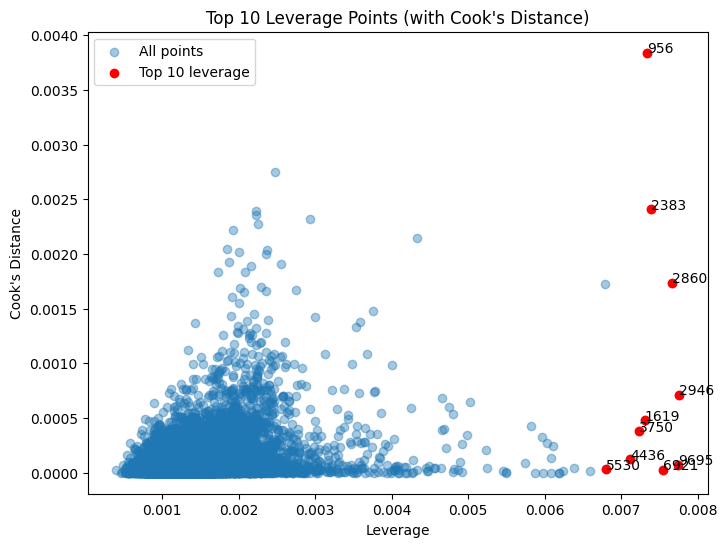

In [73]:
influence = OLS.get_influence()
summary = influence.summary_frame()

# Get leverage and Cook's distance
leverage = summary['hat_diag']
cooks_d = summary['cooks_d']

# Find top 10 highest leverage points
top_10_leverage_idx = leverage.sort_values(ascending=False).head(10).index

# Plot all points (optional for context)
plt.figure(figsize=(8, 6))
plt.scatter(leverage, cooks_d, alpha=0.4, label='All points')

# Highlight top 10 leverage points
plt.scatter(leverage.loc[top_10_leverage_idx], cooks_d.loc[top_10_leverage_idx], 
            color='red', label='Top 10 leverage')

# Annotate with original X_train indices
for i in top_10_leverage_idx:
    plt.annotate(i, (leverage.loc[i], cooks_d.loc[i]))

plt.xlabel("Leverage")
plt.ylabel("Cook's Distance")
plt.title("Top 10 Leverage Points (with Cook's Distance)")
plt.legend()
plt.show()

In [74]:
X_train.loc[956]

const                         1.000000
site_area                     1.657686
water_consumption             1.420030
recycling_rate                0.530384
utilisation_rate             -1.262252
air_qality_index             -0.076453
issue_reolution_time          0.614782
resident_count                3.697191
structure_Industrial          0.000000
structure_Mixed               1.000000
structure_Residential         0.000000
Mixed:resident_count          6.124886
Residential:resident_count   -0.583567
Name: 956, dtype: float64

# Fit XGB model

XGBoost R2: 0.9632839974429322
XGBoost MSE: 43996.79600212026
XGBoost MAE: 167.3631163330078


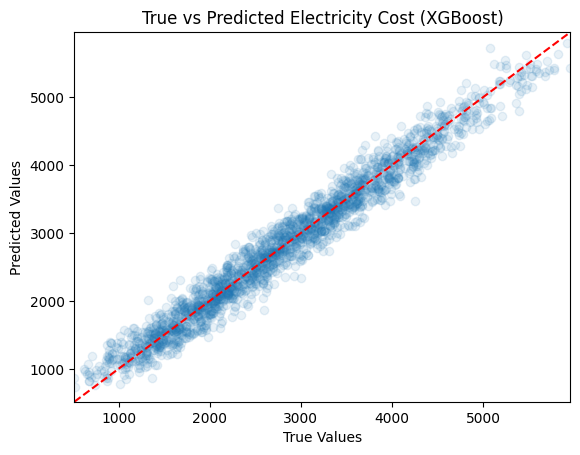

In [86]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

from sklearn.metrics import mean_squared_error as MSE, mean_absolute_error as MAE, r2_score
print(f"XGBoost R2: {r2_score(y_test, xgb_preds)}")
print(f"XGBoost MSE: {MSE(y_test, xgb_preds)}")
print(f"XGBoost MAE: {MAE(y_test, xgb_preds)}")
# Prediction against true values
plt.scatter(y_test, xgb_preds, alpha=0.1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Electricity Cost (XGBoost)")
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.show()
# Feature importance